# Evaluasi Struktur Biaya, Subsidi Pengiriman, dan Risiko Pembatalan pada Transaksi E-Commerce Indonesia

## Latar Belakang dan Tujuan Analisis
Proyek ini bertujuan untuk:
- Mengevaluasi struktur biaya pengiriman dan efisiensi logistik
- Menilai efektivitas subsidi pengiriman terhadap risiko operasional
- Mengidentifikasi faktor-faktor yang berkontribusi terhadap pembatalan pesanan
- Menentukan area atau segmen yang menunjukkan indikasi inefisiensi operasional

Analisis difokuskan pada segmentasi berdasarkan:
- Provinsi
- Metode pembayaran
- Kategori produk

Karena sebagian besar data tidak memiliki informasi waktu yang lengkap, analisis tidak difokuskan pada tren waktu, melainkan pada evaluasi struktural dan segmentasi operasional.

**Output :** Hasil analisis diharapkan dapat memberikan rekomendasi terkait optimalisasi subsidi, pengendalian biaya logistik, dan prioritas perbaikan operasional berdasarkan segmentasi wilayah dan metode pembayaran.

In [31]:
#Import library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [32]:
# Setting tampilan
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

# Setting gaya visual
sns.set_theme(style="whitegrid")

____
## 1. Data Understanding
Pada bagian ini yang dilakukan meliputi:
- Load dataset
- Cek struktur kolom, tipe data, missing values, dan ringkasan statistik awal



### Load Dataset

In [33]:

url = "https://raw.githubusercontent.com/AlvitoDwiP/operasional_ecommers_indo/refs/heads/main/data/raw/all_months_clean.csv"
df = pd.read_csv(
    url,
    sep=";",               
    encoding="utf-8-sig",  
    engine="python"
)

print("Shape:", df.shape)
df.head()


Shape: (20848, 19)


,order_id,total_qty,total_weight_gr,total_returned_qty,Total Diskon,product_categories,num_product_categories,Status Pesanan,Alasan Pembatalan,Opsi Pengiriman,Metode Pembayaran,Kota/Kabupaten,Provinsi,Ongkos Kirim Dibayar oleh Pembeli,Estimasi Potongan Biaya Pengiriman,Total Pembayaran,Perkiraan Ongkos Kirim,Waktu Pesanan Dibuat,source_file
0,ORD_0000001,2,2000,0,0,Celengan,1,Selesai,NaN,Reguler (Cashless)-SPX Standard,Saldo ShopeePay,KOTA SERANG,BANTEN,0,10000,38300,10000,2024-04-01 00:15,AprilSales2024.xlsx
1,ORD_0000002,1,500,0,0,Celengan,1,Selesai,NaN,Hemat Kargo-SPX Hemat,COD (Bayar di Tempat),KOTA SEMARANG,JAWA TENGAH,0,14500,18576,14500,2024-04-01 01:47,AprilSales2024.xlsx
2,ORD_0000003,1,500,0,0,Celengan,1,Selesai,NaN,Hemat Kargo-SPX Hemat,SeaBank Bayar Instan,KAB. BOGOR,JAWA BARAT,0,8000,7069,8000,2024-04-01 04:25,AprilSales2024.xlsx
3,ORD_0000004,2,400,0,0,Mangkok Sambal / Saus,1,Selesai,NaN,Hemat Kargo-SPX Hemat,COD (Bayar di Tempat),KOTA JAMBI,JAMBI,0,20000,32200,20000,2024-04-01 04:41,AprilSales2024.xlsx
4,ORD_0000005,3,3600,0,0,"Keranjang, Other, Tempat Nasi",3,Batal,Dibatalkan oleh Pembeli. Alasan: Ubah Pesanan ...,Hemat Kargo-SPX Hemat,COD (Bayar di Tempat),KOTA TANGERANG,BANTEN,0,0,0,8000,2024-04-01 06:12,AprilSales2024.xlsx


Insight:

Dataset terdiri dari sejumlah transaksi tingkat pesanan (order-level), setiap baris merepresentasikan satu pesanan, dataset siap untuk proses eksplorasi struktur dan kualitas data.

### Cek struktur kolom, tipe data, missing values, dan ringkasan statistik awal

In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20848 entries, 0 to 20847
Data columns (total 19 columns):
 #   Column                              Non-Null Count  Dtype 
---  ------                              --------------  ----- 
 0   order_id                            20848 non-null  object
 1   total_qty                           20848 non-null  int64 
 2   total_weight_gr                     20848 non-null  int64 
 3   total_returned_qty                  20848 non-null  int64 
 4   Total Diskon                        20848 non-null  int64 
 5   product_categories                  20848 non-null  object
 6   num_product_categories              20848 non-null  int64 
 7   Status Pesanan                      20848 non-null  object
 8   Alasan Pembatalan                   2830 non-null   object
 9   Opsi Pengiriman                     20848 non-null  object
 10  Metode Pembayaran                   20848 non-null  object
 11  Kota/Kabupaten                      20848 non-null  ob

**Interpretasi:**
dataset berisi 20.848 baris dengan mayoritas kolom sudah lengkap dan tipe numerik utama sudah benar, namun Alasan Pembatalan sangat banyak kosong (wajar jika hanya untuk order batal) serta Waktu Pesanan Dibuat masih bertipe teks dan sebagian null sehingga perlu dibersihkan dulu sebelum analisis waktu.

#### **Cek Missing values**

In [35]:
missing = df.isna().sum().sort_values(ascending=False).to_frame("Missing Count")
missing["Missing (%)"] = (missing["Missing Count"] / len(df) * 100).round(2)
missing.head(10)


,Missing Count,Missing (%)
Alasan Pembatalan,18018,86.43
Waktu Pesanan Dibuat,1980,9.50
order_id,0,0.00
total_weight_gr,0,0.00
total_qty,0,0.00
product_categories,0,0.00
total_returned_qty,0,0.00
num_product_categories,0,0.00
Status Pesanan,0,0.00
Opsi Pengiriman,0,0.00


**Interpretasi:**
- Waktu Pesanan Dibuat missing besar → tren bulanan tidak dipakai.
- Analisis difokuskan pada evaluasi struktural dan segmentasi operasional, bukan tren waktu.

#### **Statistik deskriptif numerik**

In [36]:
df.describe(include="number").T


,count,mean,std,min,25%,50%,75%,max
total_qty,20848.0,2.560821,7.796763,1.0,1.0,1.0,2.0,256.0
total_weight_gr,20848.0,2004.529691,7106.357515,10.0,300.0,500.0,1600.0,375000.0
total_returned_qty,20848.0,0.017748,0.548656,0.0,0.0,0.0,0.0,70.0
Total Diskon,20848.0,405.199348,9784.017705,0.0,0.0,0.0,0.0,700000.0
num_product_categories,20848.0,1.112097,0.485361,1.0,1.0,1.0,1.0,11.0
Ongkos Kirim Dibayar oleh Pembeli,20848.0,4189.990695,13578.489678,0.0,0.0,0.0,3000.0,584000.0
Estimasi Potongan Biaya Pengiriman,20848.0,10722.539284,12672.471066,0.0,0.0,9500.0,15000.0,312000.0
Total Pembayaran,20848.0,50683.597036,144019.263221,0.0,13480.0,21800.0,41600.0,3403591.0
Perkiraan Ongkos Kirim,20848.0,18425.626343,23791.508665,1.0,8000.0,11000.0,20000.0,959200.0


- Untuk “sanity check”: tidak boleh ada ongkir negatif, berat negatif, qty negatif.
- Jika max terlalu ekstrem → nanti kita handle outlier (bukan dihapus langsung, tapi di-clip/winsorize untuk visualisasi).



### Gambaran Operasional Cepat (Grafik kuat)
Bagian ini bertujuan untuk memahami kondisi operasional secara umum sebelum masuk ke analisis biaya dan subsidi.
Kita akan melihat:
- Distribusi status pesanan
- Tingkat pembatalan keseluruhan
- Wilayah dengan volume transaksi terbesar

#### A) Distribusi status pesanan

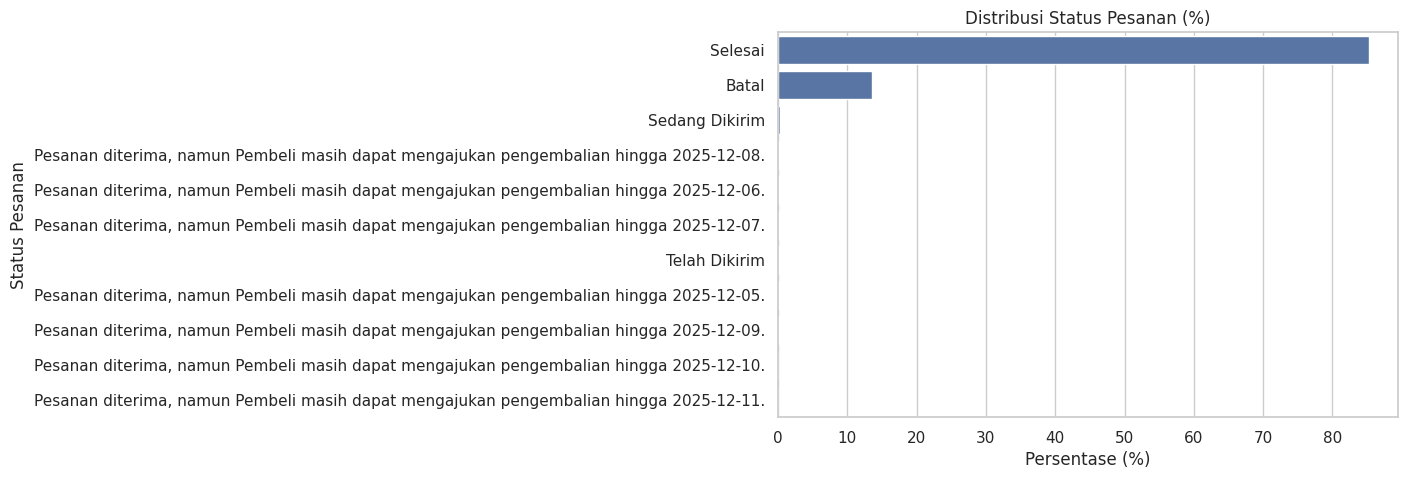

In [41]:
status_dist = df["Status Pesanan"].value_counts(normalize=True) * 100

plt.figure(figsize=(8,5))
sns.barplot(x=status_dist.values, y=status_dist.index)
plt.title("Distribusi Status Pesanan (%)")
plt.xlabel("Persentase (%)")
plt.ylabel("Status Pesanan")
plt.show()



**Insight**
Grafik ini menunjukkan bagaimana kondisi akhir setiap pesanan dalam sistem.
Beberapa poin penting yang bisa diperhatikan:
- Status “Selesai” biasanya menjadi proporsi terbesar, yang menunjukkan sebagian besar transaksi berhasil diproses hingga akhir.
- Status “Batal” menjadi indikator risiko operasional. Semakin besar proporsinya, semakin besar potensi inefisiensi dalam proses transaksi.
- Status lain seperti “Sedang Dikirim” atau “Telah Dikirim” menunjukkan transaksi yang masih dalam proses atau telah mencapai tahap pengiriman.

Jika proporsi batal cukup signifikan, maka analisis lebih lanjut terhadap faktor biaya dan metode pembayaran menjadi sangat relevan.

#### B) Tingkat Pembatalan Keseluruhan

In [43]:
df["cancel_flag"] = np.where(
    df["Status Pesanan"].str.lower() == "batal", 1, 0
)

cancel_rate = df["cancel_flag"].mean() * 100
print(f"Cancellation Rate: {cancel_rate:.2f}%")


Cancellation Rate: 13.57%


**Insight**
- Cancellation rate menunjukkan persentase pesanan yang dibatalkan dari seluruh transaksi.
- Secara sederhana jika cancellation rate = 13%, berarti dari setiap 100 pesanan, sekitar 13 pesanan dibatalkan.

Ini penting karena:
- Setiap pembatalan berpotensi menyebabkan biaya logistik terbuang.
- Jika subsidi sudah diberikan sebelum pesanan dibatalkan, maka perusahaan tetap menanggung biaya tersebut.

Tingkat pembatalan yang tinggi bisa mengindikasikan masalah seperti:
- Ongkos kirim terlalu mahal
- Metode pembayaran kurang terpercaya
- Masalah stok atau pengiriman


Nilai ini akan menjadi pembanding ketika kita melihat cancellation rate per provinsi dan metode pembayaran.

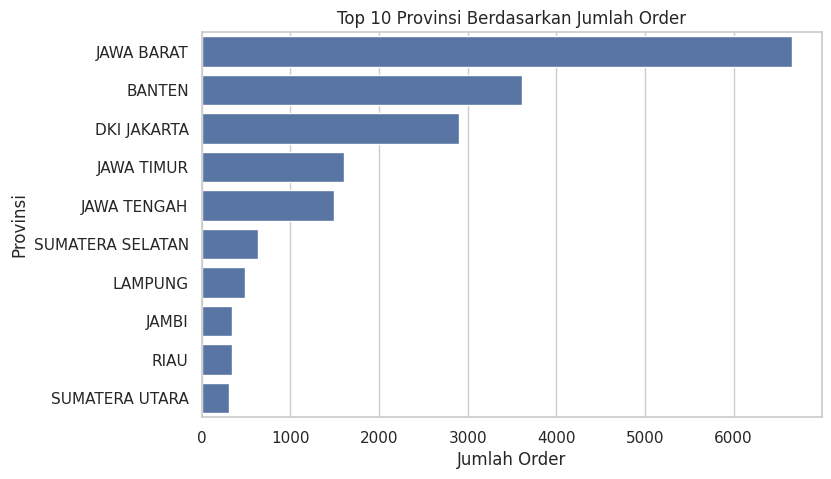

In [39]:
top_province = df["Provinsi"].value_counts().head(10)
plt.figure(figsize=(8,5))
sns.barplot(x=top_province.values, y=top_province.index)
plt.title("Top 10 Provinsi Berdasarkan Jumlah Order")
plt.xlabel("Jumlah Order"); plt.ylabel("Provinsi")
plt.show()
